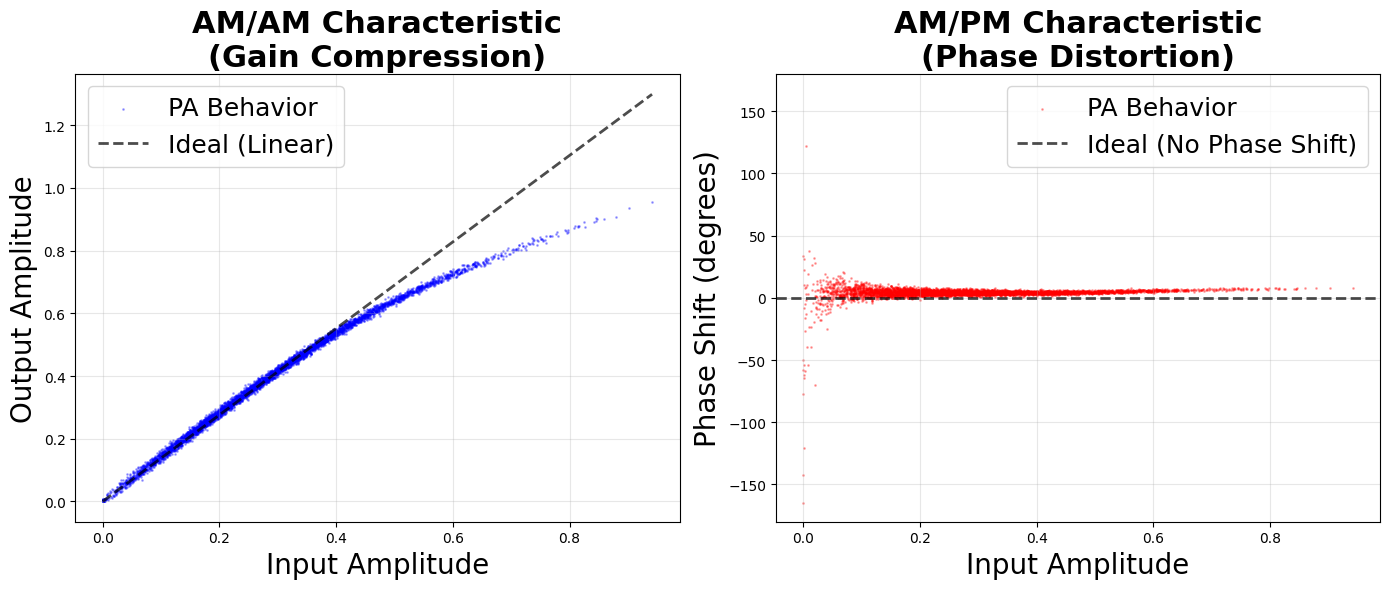


=== PA Characteristic Summary ===
Input amplitude range: 0.0002 to 0.9413
Output amplitude range: 0.0002 to 0.9549
Estimated small-signal gain: 1.3800
Phase distortion range: -837.89° to 122.07°


np.float64(-9.833420350517244)

In [2]:
from sparseDPD import DataManager, Datapath


simpleDataManager = DataManager(
    filepath='UCD_datasets/PA_IO.mat',
    num_training_points=10000,
    num_validaiton_points=2000,
    num_test_points=2000,
)


simpleDataManager.plot_pa_characteristics()
simpleDataManager.test_dataset.calculate_nmse()

ACLR (no DPD) lower: 39.71 dBc, upper: 39.96 dBc


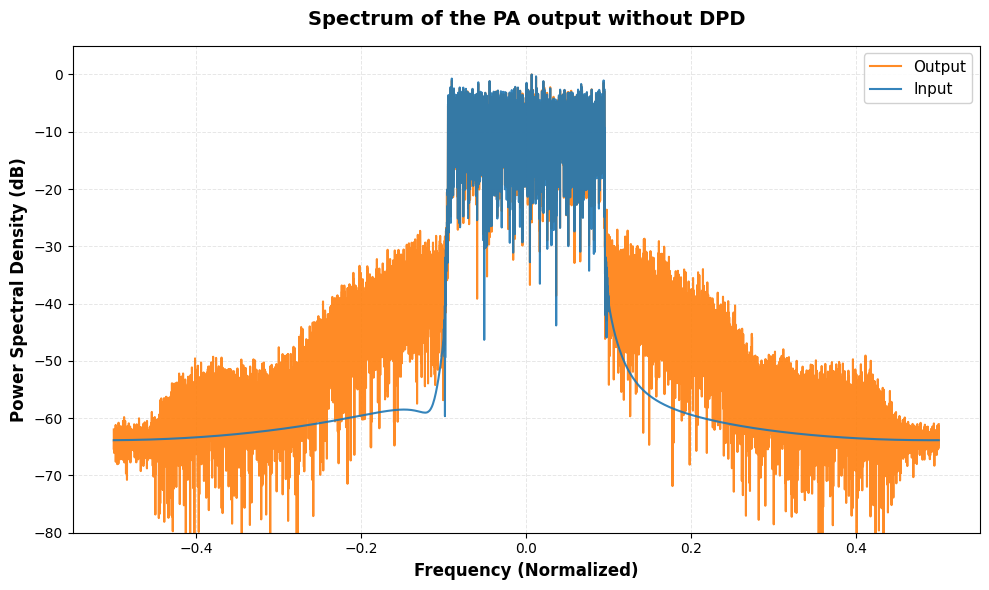

In [4]:
# Plot the spectrum with no DPD
data = simpleDataManager.test_dataset
data.plot_spectrum(
    title='Spectrum of the PA output without DPD',
    show_plot=False,
    num_points=10000,
    plot_input=True
)

# Find ACLR for PA output (no DPD) using existing Datapath ACLR utility
aclr_lower, aclr_upper = Datapath._compute_aclr(
    data.output_data,
    channel_bw=0.2,
    channel_spacing=0.3,
    fs=1.0
 )
print(f'ACLR (no DPD) lower: {aclr_lower:.2f} dBc, upper: {aclr_upper:.2f} dBc')

Using cuda device


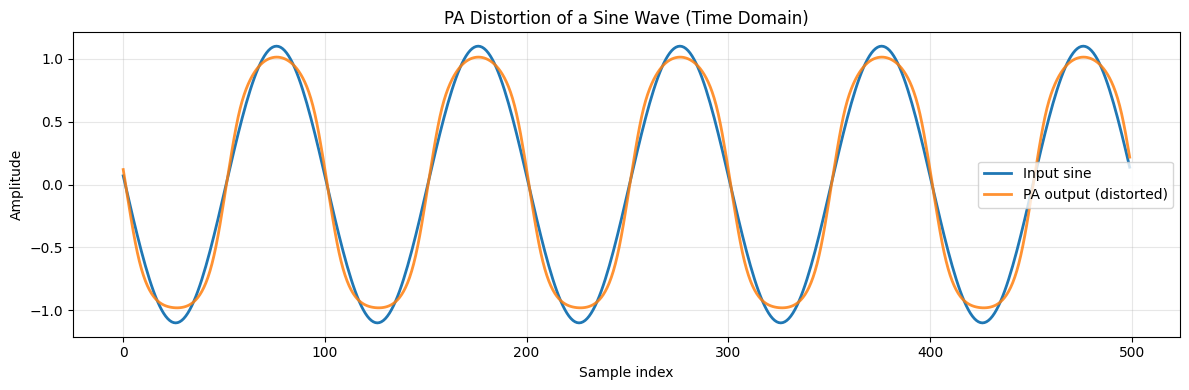

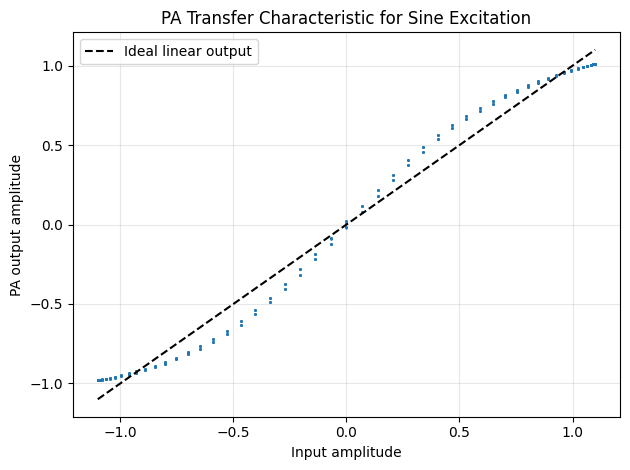

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sparseDPD.PGJANET import PGJANET_NeuralNetwork

# Load pretrained forward PA M
pa_forward = PGJANET_NeuralNetwork(
        nn_file_path='pre_trained_models/pgjanet_checkpoint.pt',
        num_memory_levels=10,
        model_type='PGJANETNetwork',
        forward_model=True,
        seq_len=10,
        seq_stride=1,
        hidden_size=16,
        batch_size=256,
)

# Generate real sine-wave input (baseband, Q=0)
n_samples = 4000
cycles = 40
amplitude = 1.1
n = np.arange(n_samples)
x_real = amplitude * np.sin(2 * np.pi * cycles * n / n_samples)
x = x_real.astype(np.complex128)

# Pass through PA forward ModuleNotFoundError
y = pa_forward.generate_model_output(x)

# Align input length with model output (PGJANET trims seq_len-1 samples)
trim = pa_forward.seq_len - 1
x_aligned = x[trim:]

# Time-domain comparison over a short window
window = 500
t = np.arange(window)

plt.figure(figsize=(12, 4))
plt.plot(t, np.real(x_aligned[:window]), label='Input sine', linewidth=2)
plt.plot(t, np.real(y[:window]), label='PA output (distorted)', linewidth=2, alpha=0.85)
plt.xlabel('Sample index')
plt.ylabel('Amplitude')
plt.title('PA Distortion of a Sine Wave (Time Domain)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Transfer curve: input vs clear_outputplt.figure(figsize=(6, 6))
plt.plot(np.real(x_aligned), np.real(y), '.', markersize=1, alpha=0.25)
lims = [np.min(np.real(x_aligned)), np.max(np.real(x_aligned))]
plt.plot(lims, lims, 'k--', linewidth=1.5, label='Ideal linear output')
plt.xlabel('Input amplitude')
plt.ylabel('PA output amplitude')
plt.title('PA Transfer Characteristic for Sine Excitation')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


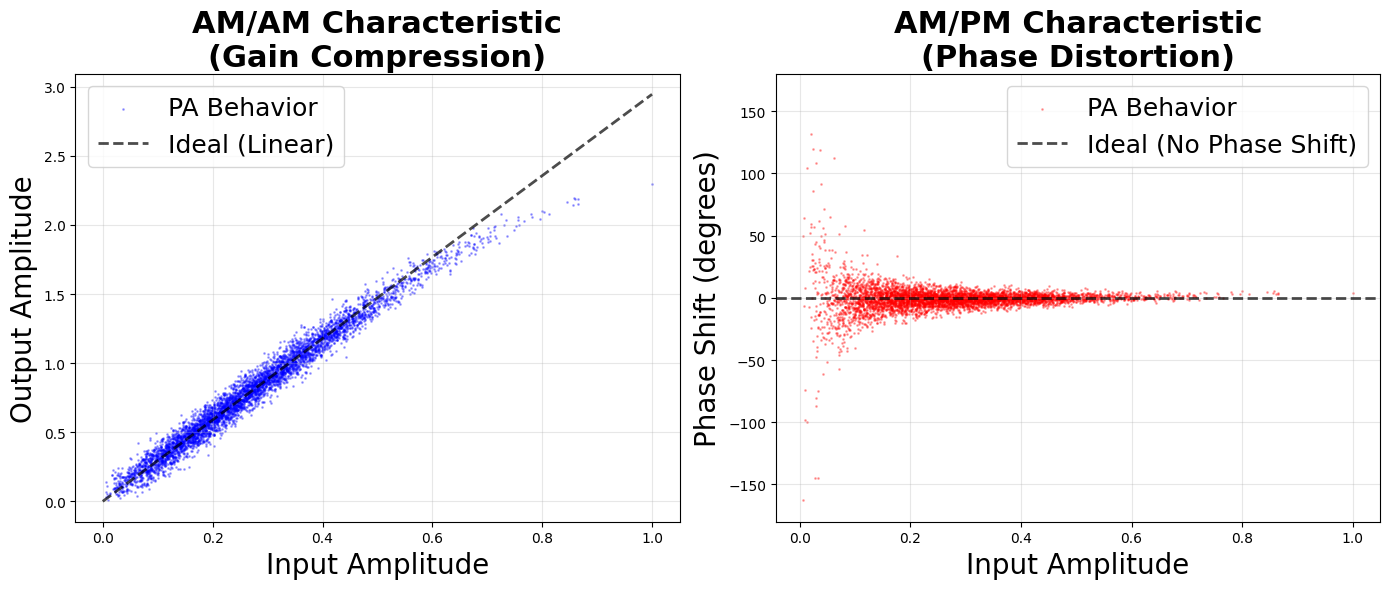


=== PA Characteristic Summary ===
Input amplitude range: 0.0062 to 0.9996
Output amplitude range: 0.0123 to 2.2926
Estimated small-signal gain: 2.9465
Phase distortion range: -162.89° to 368.78°


np.float64(5.719698944579408)

In [6]:
# Same dataset/training style as refactored_notebook.ipynb
openDPD_folder = 'OpenDPD_datasets/DPA_160MHz'

#40,000 points
openDPD_dataManager = DataManager(
    num_test_points=98304,
    num_training_points=294912,
    num_validaiton_points=98304,
    openDPD_test_input_file=f'{openDPD_folder}/test_input.csv',
    openDPD_test_output_file=f'{openDPD_folder}/test_output.csv',
    openDPD_training_input_file=f'{openDPD_folder}/train_input.csv',
    openDPD_training_output_file=f'{openDPD_folder}/train_output.csv',
    openDPD_validation_input_file=f'{openDPD_folder}/val_input.csv',
    openDPD_validation_output_file=f'{openDPD_folder}/val_output.csv'
)

openDPD_dataManager.plot_pa_characteristics()
openDPD_dataManager.test_dataset.calculate_nmse()


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Spectrum of the PA output without DPD'}, xlabel='Frequency (Normalized)', ylabel='Power Spectral Density (dB)'>)

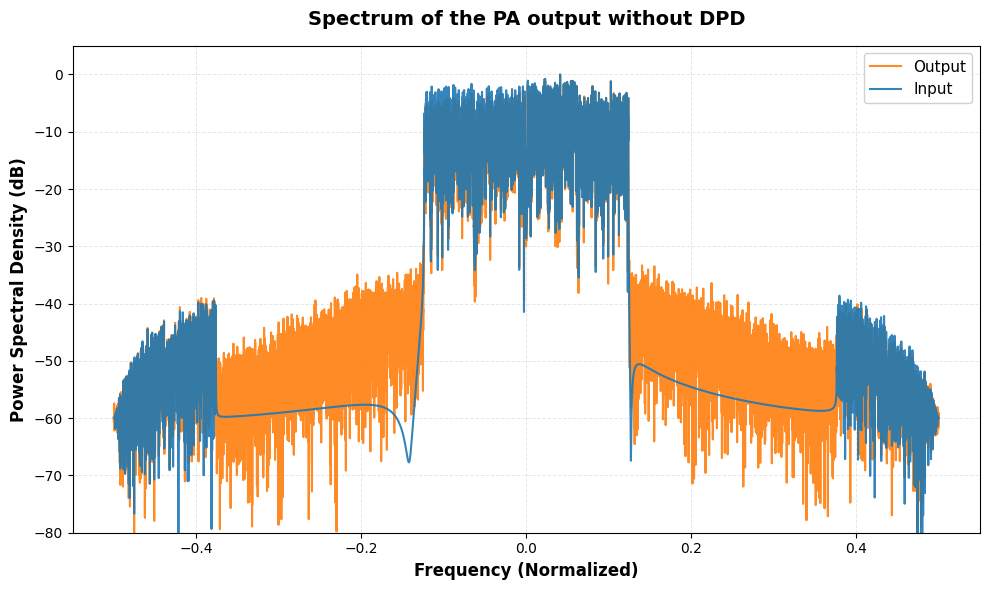

In [4]:
# Plot the spectrum with no DPD
data = openDPD_dataManager.test_dataset
data.plot_spectrum(
    title='Spectrum of the PA output without DPD',
    show_plot=False,
    num_points=10000,
    plot_input=True
)

Total subcarriers (1 carrier): 1024, Active (after guard band filtering): 983


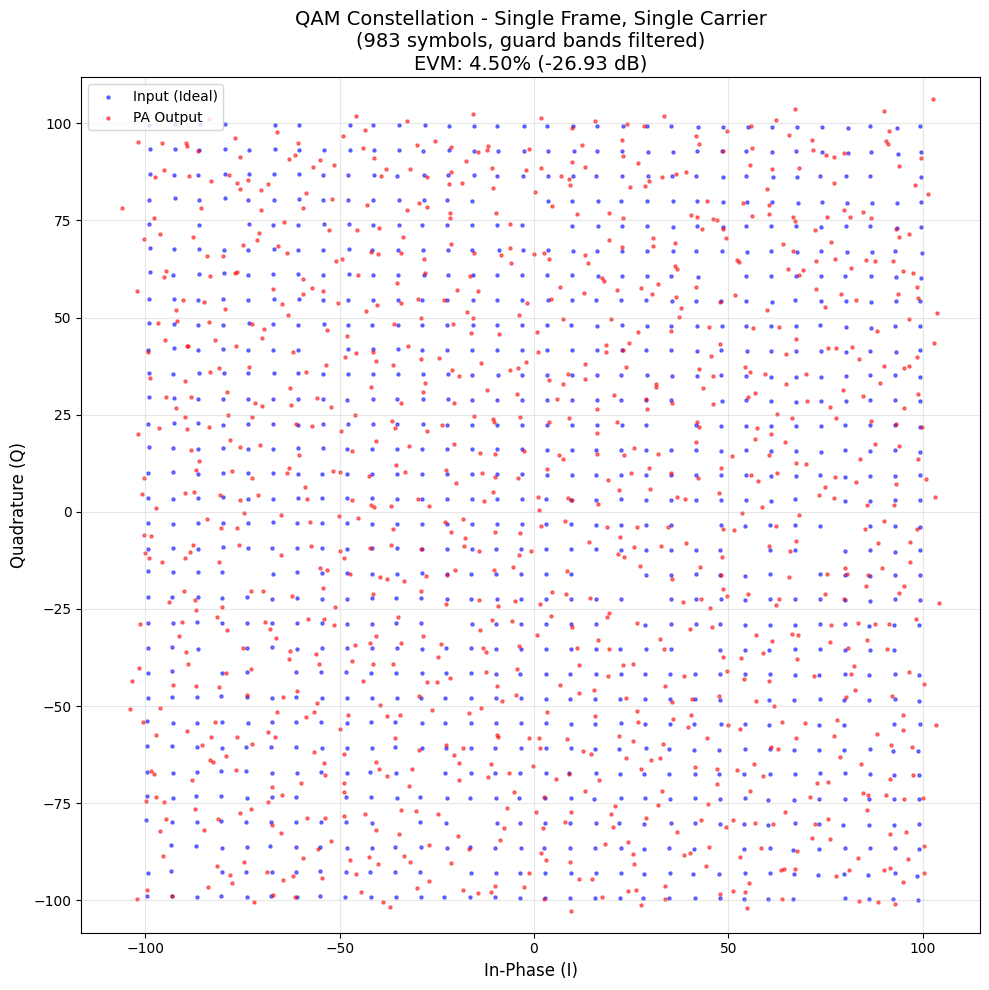

EVM (RMS): 4.502%
EVM (dB): -26.932 dB


(np.float64(4.502129246484146), np.float64(-26.931640829850085))

In [ ]:
# Setup a datapath to plot the QAM signal
openDPD_fs = 640e6  # Sampling frequency: 640 MHz
openDPD_bw_main_ch = 160e6  # Main channel bandwidth: 160 MHz
openDPD_bw_sub_ch = 40e6  # Sub-channel bandwidth: 40 MHz
openDPD_n_sub_ch = 4  # Number of sub-channels
openDPD_nperseg = 16384  # FFT size (frame length)s
data.plot_constellation(
    fs = openDPD_fs,
    bw_sub_ch=openDPD_bw_sub_ch,
    n_sub_ch=openDPD_n_sub_ch,
    nperseg=openDPD_nperseg
)

ACLR (no DPD) lower: 36.87 dBc, upper: 35.72 dBc


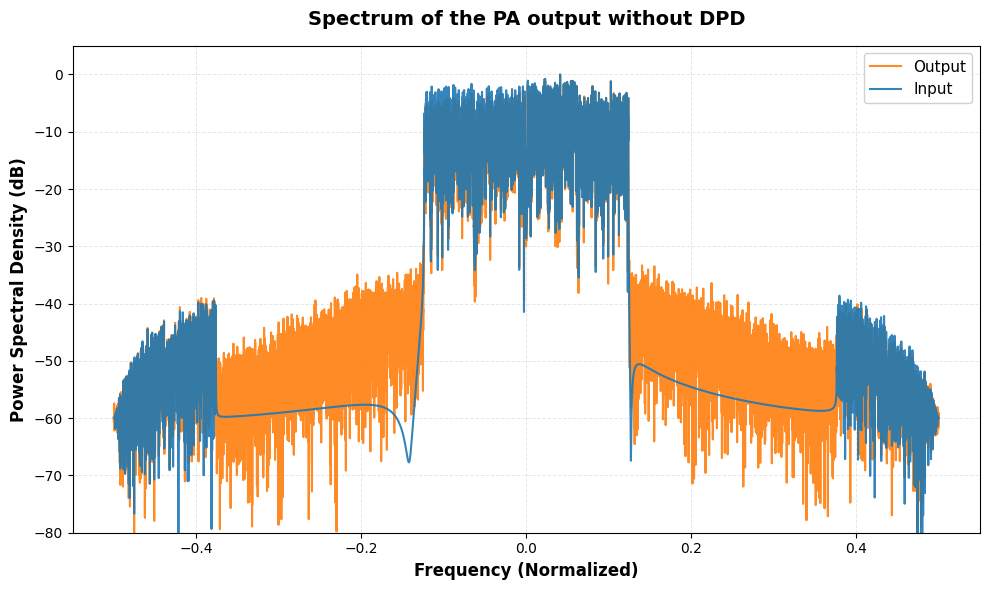

In [7]:
# Plot the spectrum with no DPD
data = openDPD_dataManager.test_dataset
data.plot_spectrum(
    title='Spectrum of the PA output without DPD',
    show_plot=False,
    num_points=10000,
    plot_input=True
)

# Find ACLR for PA output (no DPD) using existing Datapath ACLR utility
aclr_lower, aclr_upper = Datapath._compute_aclr(
    data.output_data,
    channel_bw=0.25,
    channel_spacing=0.25,
    fs=1.0
 )
print(f'ACLR (no DPD) lower: {aclr_lower:.2f} dBc, upper: {aclr_upper:.2f} dBc')